In [4]:
import cv2
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import os


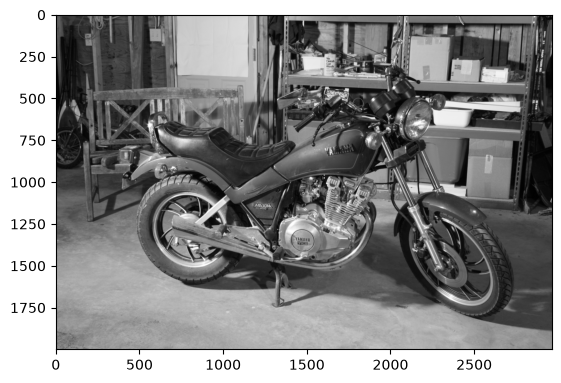

In [5]:
LeftImage1C = cv2.imread('dataset/im0/im0.png')
LeftImage1 = cv2.cvtColor(LeftImage1C , cv2.COLOR_BGR2GRAY)
LeftImage1 = np.asarray(LeftImage1)
plt.imshow(LeftImage1,cmap = 'gray')

# cv2.imshow(RightImage1)

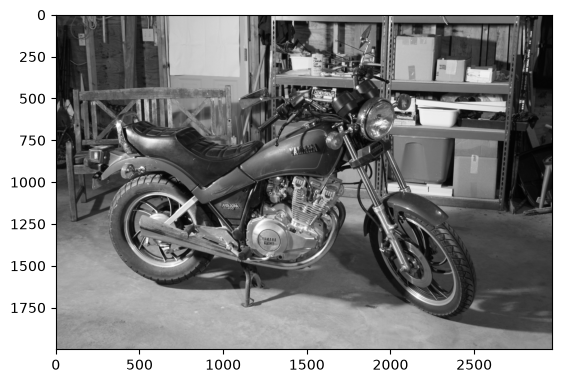

In [6]:
RightImage1 = cv2.imread('dataset/im0/im1.png',0)

RightImage1 = np.asarray(RightImage1)
plt.imshow(RightImage1,cmap = 'gray')

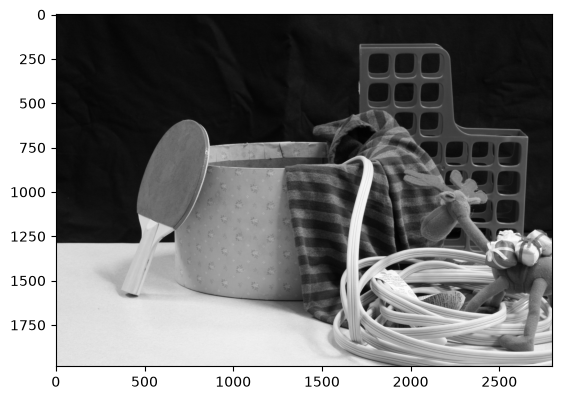

In [7]:
LeftImage2 = cv2.imread('dataset/img1/im0.png',0)
LeftImage2 = np.asarray(LeftImage2)
plt.imshow(LeftImage2,cmap = 'gray')

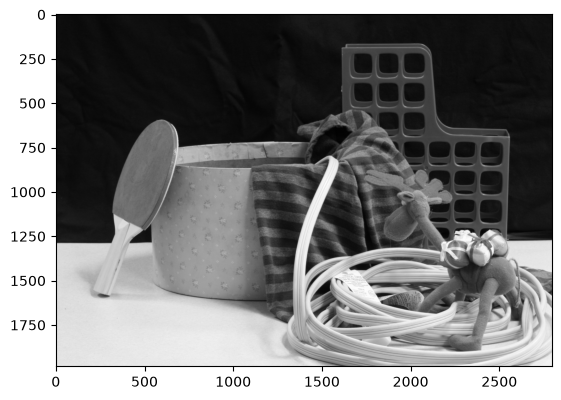

In [8]:
RightImage2 = cv2.imread('dataset/img1/im1.png',0)

RightImage2 = np.asarray(RightImage2)
plt.imshow(RightImage2,cmap = 'gray')

In [62]:
def disp(imgL,imgR,disparity,blockSize):
    stereo  = cv2.StereoBM_create(numDisparities = disparity , blockSize = blockSize)
    disparity = stereo.compute(imgL,imgR)
    disparityNormal = cv2.normalize(disparity,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
    colorMap = cv2.applyColorMap(disparityNormal, cv2.COLORMAP_JET)
    plt.imshow(disparityNormal,'gray')
    plt.show()
    return disparity , colorMap

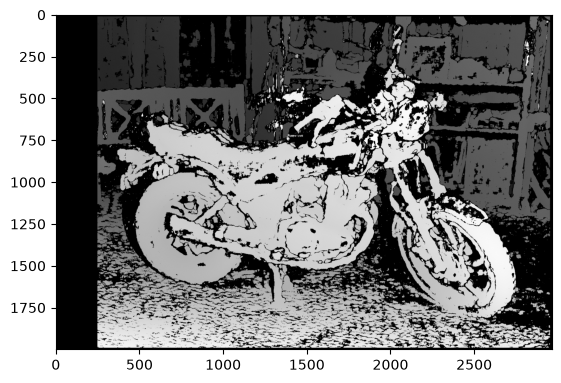

In [63]:
image1,ColorMap1 = disp(LeftImage1,RightImage1,240,21)

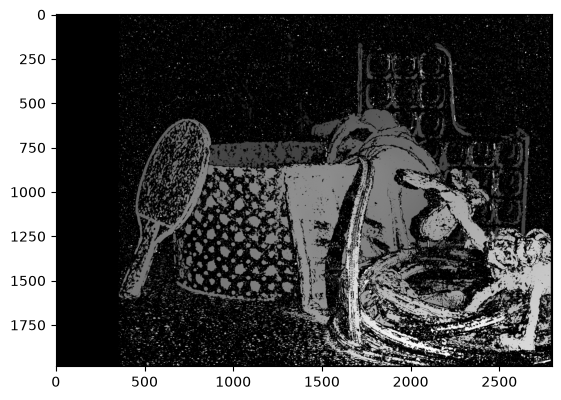

In [64]:
image2,ColorMap2 = disp(LeftImage2,RightImage2,352,11)

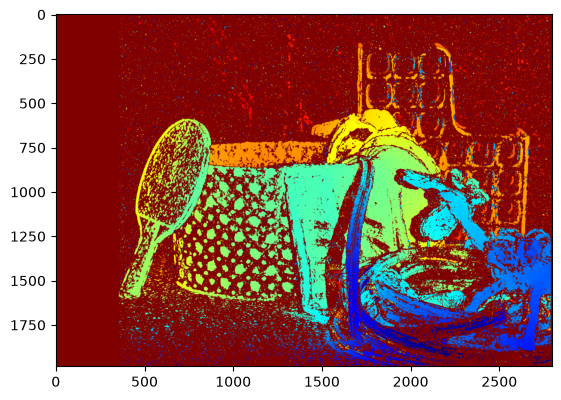

In [65]:
plt.imshow(ColorMap2)
plt.show()

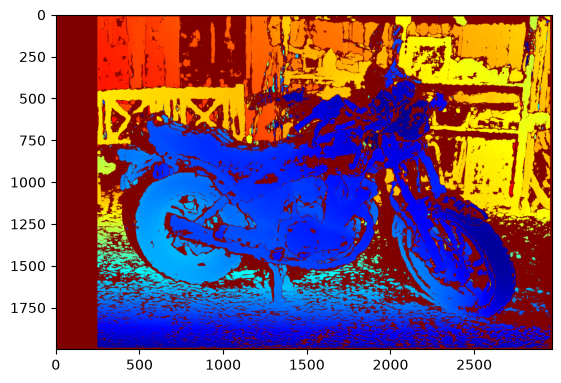

In [66]:
plt.imshow(ColorMap1)
plt.show()

In [67]:
cv2.imwrite('dataset/colormap1.png',ColorMap1)
cv2.imwrite('dataset/colormap2.png',ColorMap2)

True

In [68]:

cam01=np.array([[3979.911,     0,      1244.772],
                           [0,        3979.911, 1019.507],
                           [0,          0,        1      ]]) 
cam11=np.array([[3979.911,     0,      1369.115],
                                [0,        3979.911, 1019.507],
                                [0,          0,        1      ]])
doffs1=124.343 
baseline1=193.001
width1=2964
height1=2000
ndisp1=270 


In [69]:
cam02 = np.array([[6338.47, 0, 1035.675],
                  [0, 6338.47, 960.073],
                  [0, 0, 1]])
cam12 = np.array([[6338.47, 0, 1515.164],
                                  [0, 6338.47, 960.073],
                                  [0, 0, 1]])
doffs2=479.489 # disparity offset, add this when getting the 3d coordinate as this 2 specific images have different principle points
baseline2=171.548
width2=2796
height2=1984
ndisp2=390  # number of  disparities


In [70]:
def depth_calculation(fx,baseline,disparity,doffs):
    disp = disparity/16.0
    return fx*baseline / (disp+doffs)
    

In [71]:
x,y = 1000,500
Valuedisp = image1[y,x]
depth1 = depth_calculation(3979.911,baseline1,Valuedisp,doffs1)
depth1

np.float64(3840.0484071729056)

In [72]:
x,y = 1000,500
Valuedisp = image2[y,x]
depth2 = depth_calculation(3979.911,baseline1,Valuedisp,doffs1)
depth2

np.float64(6227.5670521310485)

In [73]:
def calculateXY(x,y,calibx,caliby,z,fx):
    newX = (x-calibx)*z/fx
    newY = (y-caliby)*z/fx
    return newX,newY

In [74]:
def writePly(image, height, width, disparity, calibx, caliby, fx, baseline, doffs,filename):
    xs, ys = np.meshgrid(np.arange(width), np.arange(height))
    Z = depth_calculation(fx,baseline,disparity,doffs)
    X,Y = calculateXY(xs,ys,calibx,caliby,Z,fx)
    valid = (disparity/16.0)>0
    colors = cv2.cvtColor(LeftImage1C,cv2.COLOR_BGR2RGB)
    colors =colors[valid]
    points = np.stack([X[valid],Y[valid],Z[valid]],axis=1)
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {points.shape[0]}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        for p, c in zip(points, colors):
            f.write(f"{p[0]} {p[1]} {p[2]} {c[0]} {c[1]} {c[2]}\n")

In [75]:
writePly(LeftImage1, height1, width1, image1, 1244.772, 1019.507, 3979.911, baseline1, doffs1, "image1.ply")

In [ ]:
!git add .